# SISE — Data Exploration (01_data_exploration)

This notebook builds and validates the local SISE “silver” dataset:
- issuer master
- filings
- GDELT-like issuer-day events
- macro series (FRED-like)
- factor returns (Ken French-like)
- issuer prices
- synthetic enterprise wrapper tables: holdings + policy constraints

Outputs:
- schema-checked silver tables + EDA plots
- readiness checks for downstream modeling notebooks


In [2]:
from __future__ import annotations

import os
import json
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200) # display all columns
pd.set_option("display.width", 140)  # set display width to 140 characters

RNG_SEED = 7 # for reproducibility
rng = np.random.default_rng(RNG_SEED)  # create a random number generator with the specified seed


## Assumptions (explicit)


1. If live public data sources like SEC, FRED, GDELT, Ken French, or market prices are not available, the notebooks will create synthetic data instead. This synthetic data is designed to keep the same table structure, level of detail, and important behavior patterns needed for the project, such as event spikes, macro trends, and factor-return movement.

2. These notebooks do not model the real-world delay in when macroeconomic data gets released. For this project, macro data is treated as available in a simplified way.

3. The notebooks are built to run locally and be easy to follow. If this project is moved toward production, most of the reusable logic should later be moved into `src/` modules.


In [3]:
# Cell 1 for code

def resolve_proj_root()-> Path:
    cwd= Path.cwd().resolve()  # get the current working directory
    if (cwd/'data').exists():
        return cwd
    if (cwd.parent/'data').exists():    
        return cwd.parent
    return cwd.parent    #return the project root directory


PROJECT_ROOT = resolve_proj_root()  #WHERE THE PROJECT ROOT AND DATA IS LOCATED
DATA_ROOT = PROJECT_ROOT / 'data'
BRONZE= DATA_ROOT / 'bronze'
SILVER= DATA_ROOT / 'silver'
GOLD= DATA_ROOT / 'gold'


for p in [BRONZE, SILVER, GOLD]:
    p.mkdir(parents=True, exist_ok=True)


# parquet files if only can be used

def parquent_available(path: Path) -> bool:
    try:
        import pyarrow
        return True
    except Exception:
        return False
    
PARQUENT_OK= parquent_available(PROJECT_ROOT)

# SAVING TABLES 
def save_table(df : pd.DataFrame, base_path_no_ext: Path) -> Path:
    base_path_no_ext.parent.mkdir(parents=True, exist_ok=True) #make sure the parent directory exists
    if PARQUENT_OK:
        out= base_path_no_ext.with_suffix('.parquet')
        df.to_parquet(out, index=False)
    out= base_path_no_ext.with_suffix('.csv')
    df.to_csv(out, index=False)
    return out



# LOADING TABLES

def load_table(base_path_no_ext: Path) -> Optional[pd.DataFrame]:
    pq= base_path_no_ext.with_suffix('.parquet')
    csv= base_path_no_ext.with_suffix('.csv')
    if pq.exists():
        return pd.read_parquet(pq)
    elif csv.exists():
        return pd.read_csv(csv)
    else:
        return None
    

# CHECKING IF TABLE EXISTS
def table_exists(base_path_no_ext: Path) -> bool:
    pq= base_path_no_ext.with_suffix('.parquet')
    csv= base_path_no_ext.with_suffix('.csv')
    return pq.exists() or csv.exists()


PROJECT_ROOT

WindowsPath('C:/ESG')

## Synthetic Dataset Generator

If real data files are not already available, this notebook creates synthetic data that follows the same structure expected by the SISE project.

The generated tables match the main datasets used in the pipeline, including:
- issuer master
- filings
- event data
- macro data
- factor return data
- price data

It also creates supporting synthetic portfolio tables like:
- holdings
- policy constraints

If these tables are already saved in `data/silver/`, the notebook will use those existing files instead of creating them again.

In [4]:
# CELL 2 FOR CODE

@dataclass
class SiseTables:
    issuer_master: pd.DataFrame
    filings: pd.DataFrame
    gdelt_events: pd.DataFrame
    macro_series: pd.DataFrame
    factor_returns_daily: pd.DataFrame
    factor_returns_monthly: pd.DataFrame
    prices: pd.DataFrame
    holdings: pd.DataFrame
    policy_constraints: pd.DataFrame

def make_business_days(start: str, end: str) -> pd.DatetimeIndex:
    return pd.bdate_range(start=start, end=end, freq="B")  #business(B) day frequency 

def simulate_issuer_master(n_issuers: int= 500) -> pd.DataFrame:

    sectors= [
        "Information Technology", "Financials", "Health Care", "Industrials",
        "Consumer Discretionary", "Consumer Staples", "Energy", "Utilities",
        "Materials", "Communication Services", "Real Estate"
    ]
    countries = ["US", "GB", "DE", "FR", "JP", "CA"]

    rows= []
    for i in range(n_issuers):
        rows.append({
            "issuer_id": f"ISSUER_{i:04d}",
            "cik": str(rng.integers(100000, 9999999)),
            "ticker": f"T{i:03d}",
            "name": f"Synthetic Corp {i:03d}",
            "sector_gics": rng.choice(sectors),
            "country": rng.choice(countries, p=[0.7, 0.05, 0.05, 0.05, 0.1, 0.05]),
            "created_at": pd.Timestamp("2022-01-01")
        })
    return pd.DataFrame(rows)


def simulate_macro_series(dates: pd.DatetimeIndex) -> pd.DataFrame:
    series_ids = ["DGS10", "CPIAUCSL", "UNRATE", "HY_SPREAD"]  #10-year Treasury yield, Consumer Price Index, Unemployment Rate, High Yield Spread
    t = np.arange(len(dates))        #time index for simulating trends and seasonality
    dgs10 = 2.5 + 0.6*np.sin(t/220) + 0.15*rng.normal(size=len(dates))   #simulate DGS10 with a base level, a slow sine wave for long-term trend, and some noise
    cpi = 280 + 0.02*t + 0.8*np.sin(t/120) + 0.3*rng.normal(size=len(dates))
    unrate = 4.0 + 0.3*np.sin(t/180) + 0.2*rng.normal(size=len(dates))
    hy = 3.5 + 0.4*np.sin(t/150) + 0.2*rng.normal(size=len(dates))
    series_map = {"DGS10": dgs10, "CPIAUCSL": cpi, "UNRATE": unrate, "HY_SPREAD": hy}

    ingest_ts = pd.Timestamp.now()   #timestamp for when the data is ingested
    out = []
    for sid in series_ids:
        for d, v in zip(dates, series_map[sid]):
            out.append({"series_id": sid, "date": d.date(), "value": float(v), "ingest_ts": ingest_ts})
    return pd.DataFrame(out)


def to_macro_wide_daily(macro_series: pd.DataFrame) -> pd.DataFrame:  
    m = macro_series.copy()   #make a copy to avoid modifying the original dataframe
    m["date"] = pd.to_datetime(m["date"])  #ensure the date column is in datetime format
    wide = m.pivot_table(index="date", columns="series_id", values="value", aggfunc="last").reset_index()  #pivot to wide format with date as index and series_id as columns, using last value if there are duplicates
    wide["date"] = wide["date"].dt.date  #convert back to date format without time
    return wide

def simulate_factor_returns(dates: pd.DatetimeIndex, macro_wide_daily: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df= macro_wide_daily.copy()  #make a copy to avoid modifying the original dataframe
    df['date']= pd.to_datetime(df['date'])  #ensure date is in datetime format
    df= df.sort_values('date')  #sort by date just in case
    rf = 0.0001 + 0.00002*rng.normal(size=len(df)) #simulate a small random risk-free rate around 0.01% daily
    eps = rng.normal(size=(len(df), 6)) * 0.005 #random noise for factor returns, scaled to have a standard deviation of about 0.5% daily

    dgs10= df['DGS10'].values #10-year Treasury yield as a proxy for the level of interest rates
    hy = df["HY_SPREAD"].to_numpy() #high yield spread as a proxy for credit risk in the market
    un = df["UNRATE"].to_numpy() #unemployment rate as a proxy for economic conditions


    #simulate factor returns with some dependence on the macro variables plus random noise
    mkt_rf = 0.0002 - 0.00005*(hy - np.mean(hy)) + eps[:, 0]
    smb    = 0.00005 - 0.00003*(un - np.mean(un)) + eps[:, 1]
    hml    = 0.00005 + 0.00002*(dgs10 - np.mean(dgs10)) + eps[:, 2]
    rmw    = 0.00004 - 0.00002*(hy - np.mean(hy)) + eps[:, 3]
    cma    = 0.00003 + 0.00002*(dgs10 - np.mean(dgs10)) + eps[:, 4]
    mom    = 0.00006 + eps[:, 5]

    daily = pd.DataFrame({
        "date": df["date"].dt.date,
        "mkt_rf": mkt_rf, "smb": smb, "hml": hml, "rmw": rmw, "cma": cma, "mom": mom, "rf": rf
    })
    #simulate monthly returns by compounding the daily returns within each month
    monthly = daily.copy()
    monthly["date"] = pd.to_datetime(monthly["date"])
    monthly = monthly.set_index("date").resample("M").sum().reset_index()
    monthly["date"] = monthly["date"].dt.date
    monthly["mom"] = monthly["mom"] + 0.1*np.concatenate([[0], monthly["mom"].values[:-1]])
    return daily, monthly


def simulate_prices(dates: pd.DatetimeIndex, issuer_master: pd.DataFrame, factor_daily: pd.DataFrame) -> pd.DataFrame:
    F = factor_daily.copy()
    F["date"] = pd.to_datetime(F["date"])
    F = F.set_index("date").loc[dates]
    factors = F[["mkt_rf", "smb", "hml", "mom"]].to_numpy()

    rows = []
    for _, r in issuer_master.iterrows():
        beta = rng.normal(loc=[1.0, 0.2, 0.1, 0.2], scale=[0.3, 0.2, 0.2, 0.3])
        idio = rng.normal(scale=0.01, size=len(dates))
        ret = factors.dot(beta)*0.5 + idio
        p0 = float(rng.uniform(20, 200))
        price = p0 * np.exp(np.cumsum(ret))
        for d, c in zip(dates, price):
            rows.append({"issuer_id": r["issuer_id"], "date": d.date(), "close": float(c)})
    return pd.DataFrame(rows)

def simulate_gdelt_events(dates: pd.DatetimeIndex, issuer_master: pd.DataFrame) -> pd.DataFrame:
    event_types = ["environment", "labor", "governance", "litigation", "privacy", "other"]
    geos = ["US", "EU", "APAC", "LATAM", "MEA"]
    ingest_base = pd.Timestamp.now()
    sector_risk_map = {"Energy": 1.6, "Utilities": 1.3, "Materials": 1.4, "Financials": 1.2}

    rows = []
    for _, r in issuer_master.iterrows():
        sector = r["sector_gics"]
        sector_risk = sector_risk_map.get(sector, 1.0)
        latent = 0.0
        for d in dates:
            latent += rng.normal(scale=0.03)
            if rng.random() < 0.002 * sector_risk:
                latent += rng.normal(loc=1.5, scale=0.3)
            lam = max(1.0, 8.0 * sector_risk * (1.0 + max(0.0, latent)))
            mentions = rng.poisson(lam=lam)
            tone = float(rng.normal(loc=-0.25*max(0.0, latent), scale=0.8))
            rows.append({
                "issuer_id": r["issuer_id"],
                "event_date": d.date(),
                "event_type": rng.choice(event_types),
                "tone_avg": tone,
                "mentions": int(mentions),
                "sources": int(rng.integers(1, 20)),
                "geo_top": rng.choice(geos),
                "ingest_ts": ingest_base + pd.Timedelta(minutes=int(rng.integers(0, 60)))
            })
    return pd.DataFrame(rows)

@dataclass
class SiseTables:
    issuer_master: pd.DataFrame
    filings: pd.DataFrame
    gdelt_events: pd.DataFrame
    macro_series: pd.DataFrame
    factor_returns_daily: pd.DataFrame
    factor_returns_monthly: pd.DataFrame
    prices: pd.DataFrame
    holdings: pd.DataFrame
    policy_constraints: pd.DataFrame

def make_business_days(start: str, end: str) -> pd.DatetimeIndex:
    return pd.bdate_range(start=start, end=end, freq="B")

def simulate_issuer_master(n_issuers: int = 40) -> pd.DataFrame:
    sectors = [
        "Information Technology", "Financials", "Health Care", "Industrials",
        "Consumer Discretionary", "Consumer Staples", "Energy", "Utilities",
        "Materials", "Communication Services", "Real Estate"
    ]
    countries = ["US", "GB", "DE", "FR", "JP", "CA"]
    rows = []
    for i in range(n_issuers):
        rows.append({
            "issuer_id": f"ISSUER_{i:04d}",
            "cik": str(rng.integers(100000, 9999999)),
            "ticker": f"T{i:03d}",
            "name": f"Synthetic Corp {i:03d}",
            "sector_gics": rng.choice(sectors),
            "country": rng.choice(countries, p=[0.7, 0.05, 0.05, 0.05, 0.1, 0.05]),
            "created_at": pd.Timestamp("2022-01-01")
        })
    return pd.DataFrame(rows)

def simulate_macro_series(dates: pd.DatetimeIndex) -> pd.DataFrame:
    series_ids = ["DGS10", "CPIAUCSL", "UNRATE", "HY_SPREAD"]
    t = np.arange(len(dates))
    dgs10 = 2.5 + 0.6*np.sin(t/220) + 0.15*rng.normal(size=len(dates))
    cpi = 280 + 0.02*t + 0.8*np.sin(t/120) + 0.3*rng.normal(size=len(dates))
    unrate = 4.0 + 0.3*np.sin(t/180) + 0.2*rng.normal(size=len(dates))
    hy = 3.5 + 0.4*np.sin(t/150) + 0.2*rng.normal(size=len(dates))
    series_map = {"DGS10": dgs10, "CPIAUCSL": cpi, "UNRATE": unrate, "HY_SPREAD": hy}
    ingest_ts = pd.Timestamp.now()

    out = []
    for sid in series_ids:
        for d, v in zip(dates, series_map[sid]):
            out.append({"series_id": sid, "date": d.date(), "value": float(v), "ingest_ts": ingest_ts})
    return pd.DataFrame(out)

def to_macro_wide_daily(macro_series: pd.DataFrame) -> pd.DataFrame:
    m = macro_series.copy()
    m["date"] = pd.to_datetime(m["date"])
    wide = m.pivot_table(index="date", columns="series_id", values="value", aggfunc="last").reset_index()
    wide["date"] = wide["date"].dt.date
    return wide

def simulate_factor_returns(dates: pd.DatetimeIndex, macro_wide_daily: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df = macro_wide_daily.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date")

    rf = 0.0001 + 0.00002*rng.normal(size=len(df))
    eps = rng.normal(size=(len(df), 6)) * 0.005

    dgs10 = df["DGS10"].to_numpy()
    hy = df["HY_SPREAD"].to_numpy()
    un = df["UNRATE"].to_numpy()

    mkt_rf = 0.0002 - 0.00005*(hy - np.mean(hy)) + eps[:, 0]
    smb    = 0.00005 - 0.00003*(un - np.mean(un)) + eps[:, 1]
    hml    = 0.00005 + 0.00002*(dgs10 - np.mean(dgs10)) + eps[:, 2]
    rmw    = 0.00004 - 0.00002*(hy - np.mean(hy)) + eps[:, 3]
    cma    = 0.00003 + 0.00002*(dgs10 - np.mean(dgs10)) + eps[:, 4]
    mom    = 0.00006 + eps[:, 5]

    daily = pd.DataFrame({
        "date": df["date"].dt.date,
        "mkt_rf": mkt_rf, "smb": smb, "hml": hml, "rmw": rmw, "cma": cma, "mom": mom, "rf": rf
    })

    monthly = daily.copy()
    monthly["date"] = pd.to_datetime(monthly["date"])
    monthly = monthly.set_index("date").resample("M").sum().reset_index()
    monthly["date"] = monthly["date"].dt.date
    monthly["mom"] = monthly["mom"] + 0.1*np.concatenate([[0], monthly["mom"].values[:-1]])
    return daily, monthly

def simulate_prices(dates: pd.DatetimeIndex, issuer_master: pd.DataFrame, factor_daily: pd.DataFrame) -> pd.DataFrame:
    F = factor_daily.copy()
    F["date"] = pd.to_datetime(F["date"])
    F = F.set_index("date").loc[dates]
    factors = F[["mkt_rf", "smb", "hml", "mom"]].to_numpy()

    rows = []
    for _, r in issuer_master.iterrows():
        beta = rng.normal(loc=[1.0, 0.2, 0.1, 0.2], scale=[0.3, 0.2, 0.2, 0.3])
        idio = rng.normal(scale=0.01, size=len(dates))
        ret = factors.dot(beta)*0.5 + idio
        p0 = float(rng.uniform(20, 200))
        price = p0 * np.exp(np.cumsum(ret))
        for d, c in zip(dates, price):
            rows.append({"issuer_id": r["issuer_id"], "date": d.date(), "close": float(c)})
    return pd.DataFrame(rows)

def simulate_gdelt_events(dates: pd.DatetimeIndex, issuer_master: pd.DataFrame) -> pd.DataFrame:
    event_types = ["environment", "labor", "governance", "litigation", "privacy", "other"]
    geos = ["US", "EU", "APAC", "LATAM", "MEA"]
    ingest_base = pd.Timestamp.now()
    sector_risk_map = {"Energy": 1.6, "Utilities": 1.3, "Materials": 1.4, "Financials": 1.2}

    rows = []
    for _, r in issuer_master.iterrows():
        sector = r["sector_gics"]
        sector_risk = sector_risk_map.get(sector, 1.0)
        latent = 0.0
        for d in dates:
            latent += rng.normal(scale=0.03)
            if rng.random() < 0.002 * sector_risk:
                latent += rng.normal(loc=1.5, scale=0.3)
            lam = max(1.0, 8.0 * sector_risk * (1.0 + max(0.0, latent)))
            mentions = rng.poisson(lam=lam)
            tone = float(rng.normal(loc=-0.25*max(0.0, latent), scale=0.8))
            rows.append({
                "issuer_id": r["issuer_id"],
                "event_date": d.date(),
                "event_type": rng.choice(event_types),
                "tone_avg": tone,
                "mentions": int(mentions),
                "sources": int(rng.integers(1, 20)),
                "geo_top": rng.choice(geos),
                "ingest_ts": ingest_base + pd.Timedelta(minutes=int(rng.integers(0, 60)))
            })
    return pd.DataFrame(rows)

def simulate_filings(dates: pd.DatetimeIndex, issuer_master: pd.DataFrame) -> pd.DataFrame:
    months = sorted(pd.to_datetime(pd.Series(dates.date).unique()).to_period("M").unique())
    quarter_ends = [p.end_time.date() for p in months if p.month in [3, 6, 9, 12]]

    rows = []
    for _, r in issuer_master.iterrows():
        for qe in quarter_ends:
            form = "10-K" if pd.Timestamp(qe).month == 12 else "10-Q"
            filing_date = (pd.Timestamp(qe) + pd.Timedelta(days=int(rng.integers(20, 45)))).date()
            if filing_date > dates[-1].date():
                continue
            filing_id = f"{r['issuer_id']}_{form}_{qe}"
            text = f"{form} filing for {r['issuer_id']}. Risk topics: climate, governance, litigation, privacy. (Synthetic placeholder.)"
            rows.append({
                "filing_id": filing_id,
                "issuer_id": r["issuer_id"],
                "form_type": form,
                "filing_date": filing_date,
                "period_end": qe,
                "url": f"https://example.com/{filing_id}",
                "raw_text": text,
                "hash": str(abs(hash(text)) % (10**12)),
            })
    return pd.DataFrame(rows)

def simulate_holdings(dates: pd.DatetimeIndex, issuer_master: pd.DataFrame, portfolio_id: str = "P1") -> pd.DataFrame:
    month_ends = pd.Series(pd.to_datetime(dates)).dt.to_period("M").drop_duplicates().dt.end_time.dt.date
    month_ends = [d for d in month_ends if d <= dates[-1].date()]
    issuers = issuer_master["issuer_id"].tolist()

    rows = []
    for d in month_ends:
        w = rng.dirichlet(alpha=np.ones(len(issuers))*0.7)
        w = 0.8*w + 0.2*(np.eye(len(issuers))[rng.integers(0, len(issuers))])
        w = w / w.sum()
        for issuer_id, weight in zip(issuers, w):
            mv = float(weight * 100_000_000)
            shares = mv / float(rng.uniform(20, 200))
            rows.append({
                "portfolio_id": portfolio_id,
                "as_of_date": d,
                "issuer_id": issuer_id,
                "weight": float(weight),
                "shares": float(shares),
                "mv_usd": float(mv),
            })
    df = pd.DataFrame(rows)
    assert np.allclose(df.groupby(["portfolio_id","as_of_date"])["weight"].sum().values, 1.0, atol=1e-6)
    return df

def simulate_policy_constraints(portfolio_id: str = "P1") -> pd.DataFrame:
    return pd.DataFrame([{
        "portfolio_id": portfolio_id,
        "policy_version": "v1",
        "max_severe_weight": 0.05,
        "min_portfolio_esg_score": 50.0,
        "excluded_sectors": json.dumps(["Thermal Coal"]),
        "effective_date": pd.Timestamp("2022-01-01").date()
    }])

def generate_sise_mock_data(start="2022-01-03", end="2025-12-31", n_issuers=40) -> SiseTables:
    dates = make_business_days(start, end)
    issuer_master = simulate_issuer_master(n_issuers)
    macro_series = simulate_macro_series(dates)
    macro_wide_daily = to_macro_wide_daily(macro_series)
    factor_daily, factor_monthly = simulate_factor_returns(dates, macro_wide_daily)
    prices = simulate_prices(dates, issuer_master, factor_daily)
    gdelt_events = simulate_gdelt_events(dates, issuer_master)
    filings = simulate_filings(dates, issuer_master)
    holdings = simulate_holdings(dates, issuer_master, "P1")
    policy = simulate_policy_constraints("P1")

    return SiseTables(
        issuer_master=issuer_master,
        filings=filings,
        gdelt_events=gdelt_events,
        macro_series=macro_series,
        factor_returns_daily=factor_daily,
        factor_returns_monthly=factor_monthly,
        prices=prices,
        holdings=holdings,
        policy_constraints=policy
    )





In [5]:
tables = generate_sise_mock_data()

In [6]:
tables.filings.head()

,filing_id,issuer_id,form_type,filing_date,period_end,url,raw_text,hash
0,ISSUER_0000_10-Q_2022-03-31,ISSUER_0000,10-Q,2022-04-29,2022-03-31,https://example.com/ISSUER_0000_10-Q_2022-03-31,10-Q filing for ISSUER_0000. Risk topics: clim...,955544651352
1,ISSUER_0000_10-Q_2022-06-30,ISSUER_0000,10-Q,2022-08-07,2022-06-30,https://example.com/ISSUER_0000_10-Q_2022-06-30,10-Q filing for ISSUER_0000. Risk topics: clim...,955544651352
2,ISSUER_0000_10-Q_2022-09-30,ISSUER_0000,10-Q,2022-11-12,2022-09-30,https://example.com/ISSUER_0000_10-Q_2022-09-30,10-Q filing for ISSUER_0000. Risk topics: clim...,955544651352
3,ISSUER_0000_10-K_2022-12-31,ISSUER_0000,10-K,2023-01-30,2022-12-31,https://example.com/ISSUER_0000_10-K_2022-12-31,10-K filing for ISSUER_0000. Risk topics: clim...,318449532251
4,ISSUER_0000_10-Q_2023-03-31,ISSUER_0000,10-Q,2023-04-29,2023-03-31,https://example.com/ISSUER_0000_10-Q_2023-03-31,10-Q filing for ISSUER_0000. Risk topics: clim...,955544651352


## Load-or-generate silver tables


## Load-or-generate SISE silver tables

If any table is missing from `data/silver/`, generate the full synthetic dataset and persist to disk.


In [7]:
# code cell 3

required = {
    "issuer_master": SILVER / "issuer_master",
    "filings": SILVER / "filings",
    "gdelt_events": SILVER / "gdelt_events",
    "macro_series": SILVER / "macro_series",
    "factor_returns_daily": SILVER / "factor_returns_daily",
    "factor_returns_monthly": SILVER / "factor_returns_monthly",
    "prices": SILVER / "prices",
    "holdings": SILVER / "holdings",
    "policy_constraints": SILVER / "policy_constraints",
}

missing = [k for k, p in required.items() if not table_exists(p)]
print("Missing silver tables:", missing)

if missing:
    t = generate_sise_mock_data()
    save_table(t.issuer_master, required["issuer_master"])
    save_table(t.filings, required["filings"])
    save_table(t.gdelt_events, required["gdelt_events"])
    save_table(t.macro_series, required["macro_series"])
    save_table(t.factor_returns_daily, required["factor_returns_daily"])
    save_table(t.factor_returns_monthly, required["factor_returns_monthly"])
    save_table(t.prices, required["prices"])
    save_table(t.holdings, required["holdings"])
    save_table(t.policy_constraints, required["policy_constraints"])

issuer_master = load_table(required["issuer_master"])
filings = load_table(required["filings"])
gdelt_events = load_table(required["gdelt_events"])
macro_series = load_table(required["macro_series"])
factor_daily = load_table(required["factor_returns_daily"])
factor_monthly = load_table(required["factor_returns_monthly"])
prices = load_table(required["prices"])
holdings = load_table(required["holdings"])
policy_constraints = load_table(required["policy_constraints"])

issuer_master.shape, gdelt_events.shape, prices.shape


Missing silver tables: ['issuer_master', 'filings', 'gdelt_events', 'macro_series', 'factor_returns_daily', 'factor_returns_monthly', 'prices', 'holdings', 'policy_constraints']


((40, 7), (41720, 8), (41720, 3))

In [8]:
print(issuer_master.shape)
print(filings.shape)
print(gdelt_events.shape)
print(macro_series.shape)
print(factor_daily.shape)
print(factor_monthly.shape)
print(prices.shape)
print(holdings.shape)
print(policy_constraints.shape)

(40, 7)
(600, 8)
(41720, 8)
(4172, 4)
(1043, 8)
(48, 8)
(41720, 3)
(1920, 6)
(1, 6)


## Data quality checks (uniqueness, RI, freshness, coverage)


In [9]:
# Cell 4 for code


# Parse dates
filings["filing_date"] = pd.to_datetime(filings["filing_date"])
gdelt_events["event_date"] = pd.to_datetime(gdelt_events["event_date"])
prices["date"] = pd.to_datetime(prices["date"])
macro_series["date"] = pd.to_datetime(macro_series["date"])
holdings["as_of_date"] = pd.to_datetime(holdings["as_of_date"])
gdelt_events["ingest_ts"] = pd.to_datetime(gdelt_events["ingest_ts"], errors="coerce")
macro_series["ingest_ts"] = pd.to_datetime(macro_series["ingest_ts"], errors="coerce")

def check_unique(df: pd.DataFrame, keys: List[str], name: str):
    dups = df[df.duplicated(keys, keep=False)]
    if len(dups) > 0:
        raise ValueError(f"[{name}] duplicate key rows: {len(dups)}")
    print(f"[{name}] uniqueness PASS")

check_unique(issuer_master, ["issuer_id"], "issuer_master")
check_unique(filings, ["filing_id"], "filings")
check_unique(gdelt_events, ["issuer_id","event_date","event_type"], "gdelt_events")
check_unique(macro_series, ["series_id","date"], "macro_series")
check_unique(prices, ["issuer_id","date"], "prices")
check_unique(holdings, ["portfolio_id","as_of_date","issuer_id"], "holdings")

def check_fk(df: pd.DataFrame, fk: str, ref: pd.DataFrame, pk: str, name: str):
    bad = df.loc[~df[fk].isin(ref[pk].unique()), fk].unique()
    if len(bad) > 0:
        raise ValueError(f"[{name}] FK FAIL; example={bad[:5]}")
    print(f"[{name}] FK PASS")

check_fk(filings, "issuer_id", issuer_master, "issuer_id", "filings")
check_fk(gdelt_events, "issuer_id", issuer_master, "issuer_id", "gdelt_events")
check_fk(prices, "issuer_id", issuer_master, "issuer_id", "prices")
check_fk(holdings, "issuer_id", issuer_master, "issuer_id", "holdings")

# Freshness gates (portfolio thresholds)
now = pd.Timestamp.now()
print("Macro ingest age:", now - macro_series["ingest_ts"].max())
print("Events ingest age:", now - gdelt_events["ingest_ts"].max())

# Coverage summary
def coverage(df: pd.DataFrame, date_col: str, name: str) -> pd.Series:
    dt = pd.to_datetime(df[date_col])
    return pd.Series({"table": name, "min": dt.min().date(), "max": dt.max().date(), "unique_dates": dt.nunique(), "rows": len(df)})

pd.DataFrame([
    coverage(prices, "date", "prices"),
    coverage(gdelt_events, "event_date", "gdelt_events"),
    coverage(macro_series, "date", "macro_series"),
    coverage(factor_daily, "date", "factor_daily"),
    coverage(factor_monthly, "date", "factor_monthly"),
    coverage(holdings, "as_of_date", "holdings"),
    coverage(filings, "filing_date", "filings"),
])


[issuer_master] uniqueness PASS
[filings] uniqueness PASS
[gdelt_events] uniqueness PASS
[macro_series] uniqueness PASS
[prices] uniqueness PASS
[holdings] uniqueness PASS
[filings] FK PASS
[gdelt_events] FK PASS
[prices] FK PASS
[holdings] FK PASS
Macro ingest age: 0 days 00:00:07.138563
Events ingest age: -1 days +23:01:06.872526


,table,min,max,unique_dates,rows
0,prices,2022-01-03,2025-12-31,1043,41720
1,gdelt_events,2022-01-03,2025-12-31,1043,41720
2,macro_series,2022-01-03,2025-12-31,1043,4172
3,factor_daily,2022-01-03,2025-12-31,1043,1043
4,factor_monthly,2022-01-31,2025-12-31,48,48
5,holdings,2022-01-31,2025-12-31,48,1920
6,filings,2022-04-21,2025-11-13,300,600


## Filing ordering check (prev < current) — anti-leakage validation


In [10]:
# cell 5 for code
fs = filings.sort_values(["issuer_id","filing_date"]).copy()
fs["prev_filing_date"] = fs.groupby("issuer_id")["filing_date"].shift(1)
bad = fs[(~fs["prev_filing_date"].isna()) & (fs["prev_filing_date"] >= fs["filing_date"])]
assert len(bad) == 0, "Filing ordering violation"
print("Filing ordering: PASS")

# quick filing distribution
fs["form_type"].value_counts()


Filing ordering: PASS


form_type
10-Q    480
10-K    120
Name: count, dtype: int64

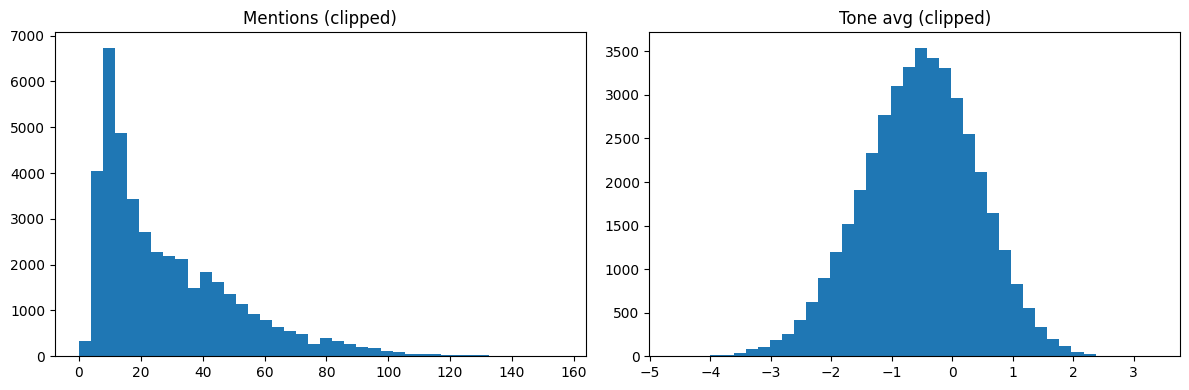

event_type
governance     7085
litigation     7009
privacy        6993
labor          6971
other          6846
environment    6816
Name: count, dtype: int64

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(gdelt_events["mentions"].clip(0, 200), bins=40)
ax[0].set_title("Mentions (clipped)")
ax[1].hist(gdelt_events["tone_avg"].clip(-5, 5), bins=40)
ax[1].set_title("Tone avg (clipped)")
plt.tight_layout()
plt.show()

gdelt_events["event_type"].value_counts()


In [12]:
filings.head()

,filing_id,issuer_id,form_type,filing_date,period_end,url,raw_text,hash
0,ISSUER_0000_10-Q_2022-03-31,ISSUER_0000,10-Q,2022-05-12,2022-03-31,https://example.com/ISSUER_0000_10-Q_2022-03-31,10-Q filing for ISSUER_0000. Risk topics: clim...,955544651352
1,ISSUER_0000_10-Q_2022-06-30,ISSUER_0000,10-Q,2022-07-31,2022-06-30,https://example.com/ISSUER_0000_10-Q_2022-06-30,10-Q filing for ISSUER_0000. Risk topics: clim...,955544651352
2,ISSUER_0000_10-Q_2022-09-30,ISSUER_0000,10-Q,2022-10-31,2022-09-30,https://example.com/ISSUER_0000_10-Q_2022-09-30,10-Q filing for ISSUER_0000. Risk topics: clim...,955544651352
3,ISSUER_0000_10-K_2022-12-31,ISSUER_0000,10-K,2023-01-30,2022-12-31,https://example.com/ISSUER_0000_10-K_2022-12-31,10-K filing for ISSUER_0000. Risk topics: clim...,318449532251
4,ISSUER_0000_10-Q_2023-03-31,ISSUER_0000,10-Q,2023-05-09,2023-03-31,https://example.com/ISSUER_0000_10-Q_2023-03-31,10-Q filing for ISSUER_0000. Risk topics: clim...,955544651352


In [13]:
filings.loc[filings["form_type"] == "10-K", ["issuer_id", "filing_date", "raw_text"]].head()

,issuer_id,filing_date,raw_text
3,ISSUER_0000,2023-01-30,10-K filing for ISSUER_0000. Risk topics: clim...
7,ISSUER_0000,2024-01-30,10-K filing for ISSUER_0000. Risk topics: clim...
11,ISSUER_0000,2025-01-23,10-K filing for ISSUER_0000. Risk topics: clim...
18,ISSUER_0001,2023-01-20,10-K filing for ISSUER_0001. Risk topics: clim...
22,ISSUER_0001,2024-01-30,10-K filing for ISSUER_0001. Risk topics: clim...


In [14]:
tenk = filings[filings["form_type"] == "10-K"].copy()
tenk.iloc[0]

filing_id                            ISSUER_0000_10-K_2022-12-31
issuer_id                                            ISSUER_0000
form_type                                                   10-K
filing_date                                  2023-01-30 00:00:00
period_end                                            2022-12-31
url              https://example.com/ISSUER_0000_10-K_2022-12-31
raw_text       10-K filing for ISSUER_0000. Risk topics: clim...
hash                                                318449532251
Name: 3, dtype: object

## Missingness + event distribution exploration


In [15]:
def missingness(df: pd.DataFrame, name: str) -> pd.DataFrame:
    m = df.isna().mean().sort_values(ascending=False).reset_index()
    m.columns = ["column","missing_rate"]
    m["table"] = name
    return m

pd.concat([
    missingness(gdelt_events, "gdelt_events"),
    missingness(macro_series, "macro_series"),
    missingness(prices, "prices"),
], ignore_index=True).head(20)


,column,missing_rate,table
0,issuer_id,0.0,gdelt_events
1,event_date,0.0,gdelt_events
2,event_type,0.0,gdelt_events
3,tone_avg,0.0,gdelt_events
4,mentions,0.0,gdelt_events
5,sources,0.0,gdelt_events
6,geo_top,0.0,gdelt_events
7,ingest_ts,0.0,gdelt_events
8,series_id,0.0,macro_series
9,date,0.0,macro_series


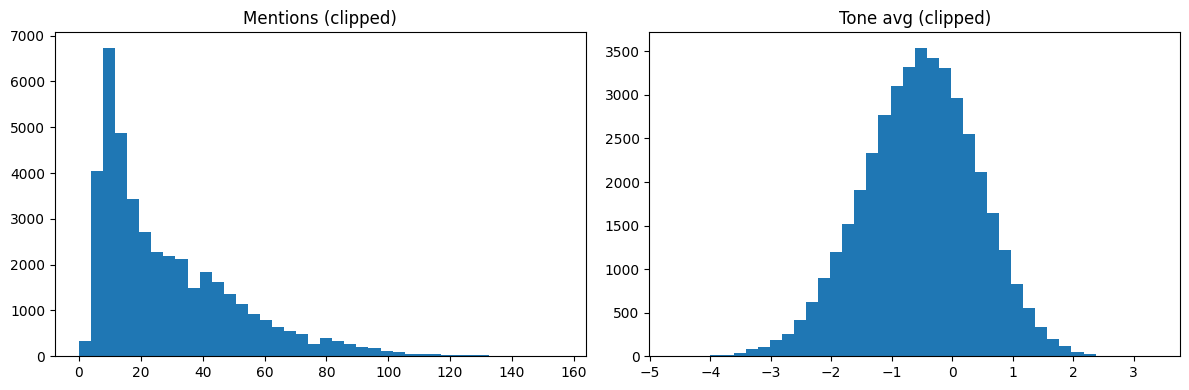

event_type
governance     7085
litigation     7009
privacy        6993
labor          6971
other          6846
environment    6816
Name: count, dtype: int64

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(gdelt_events["mentions"].clip(0, 200), bins=40)
ax[0].set_title("Mentions (clipped)")
ax[1].hist(gdelt_events["tone_avg"].clip(-5, 5), bins=40)
ax[1].set_title("Tone avg (clipped)")
plt.tight_layout()
plt.show()

gdelt_events["event_type"].value_counts()


## Portfolio holdings exploration (synthetic wrapper)

We inspect concentration and sector exposures. These support governance gating in Notebook 3.


In [17]:
def herfindahl(w: np.ndarray) -> float:
    return float(np.sum(w**2))

conc = holdings.groupby(["portfolio_id","as_of_date"]).apply(
    lambda g: pd.Series({
        "n_holdings": len(g),
        "top10_weight": float(g["weight"].nlargest(10).sum()),
        "hhi": herfindahl(g["weight"].to_numpy())
    })
).reset_index()

conc.tail()


,portfolio_id,as_of_date,n_holdings,top10_weight,hhi
43,P1,2025-08-31,40.0,0.578128,0.069356
44,P1,2025-09-30,40.0,0.685893,0.078753
45,P1,2025-10-31,40.0,0.666207,0.079132
46,P1,2025-11-30,40.0,0.624501,0.071526
47,P1,2025-12-31,40.0,0.690793,0.081270


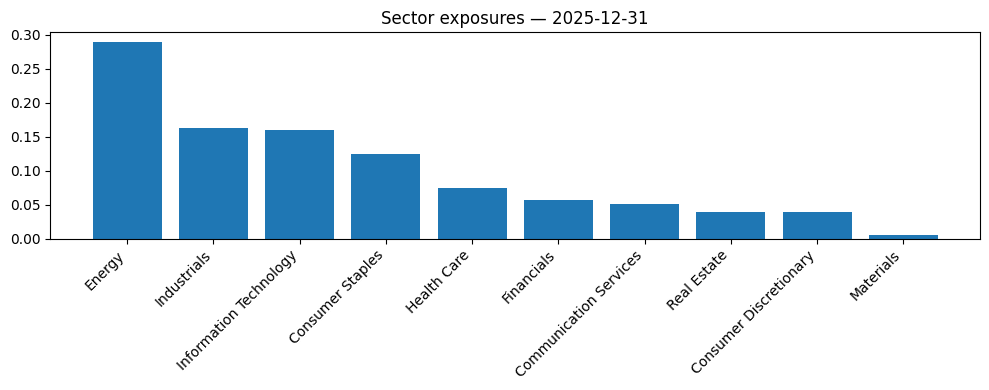

,sector_gics,weight
3,Energy,0.289448
6,Industrials,0.162880
7,Information Technology,0.159617
2,Consumer Staples,0.124315
5,Health Care,0.074275
4,Financials,0.056546
0,Communication Services,0.051122
9,Real Estate,0.038532
1,Consumer Discretionary,0.038473
8,Materials,0.004792


In [18]:
hold_sec = holdings.merge(issuer_master[["issuer_id","sector_gics"]], on="issuer_id", how="left")
latest = hold_sec["as_of_date"].max()
sec = hold_sec[hold_sec["as_of_date"]==latest].groupby("sector_gics")["weight"].sum().reset_index().sort_values("weight", ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(sec["sector_gics"], sec["weight"])
plt.xticks(rotation=45, ha="right")
plt.title(f"Sector exposures — {latest.date()}")
plt.tight_layout()
plt.show()

sec.head(10)


## Feature sanity preview (supports Notebook 2 readiness)

We compute a minimal rolling z-score spike flag to show the proxy label mechanism is feasible.


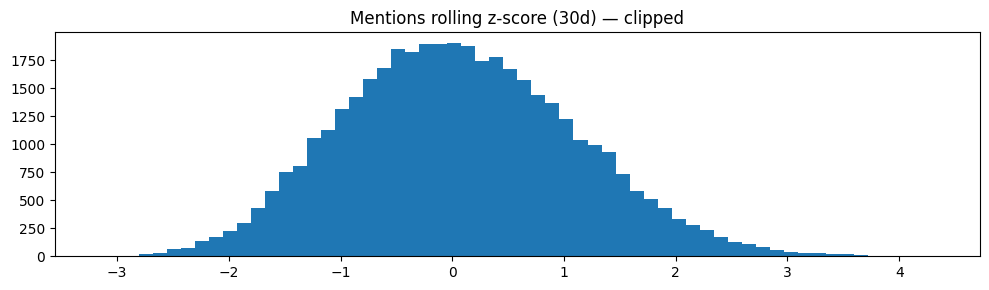

Spike frequency: 0.011697027804410355


In [19]:
def rolling_zscore(x: pd.Series, window: int) -> pd.Series:
    mu = x.rolling(window).mean()
    sd = x.rolling(window).std(ddof=0)
    return (x - mu) / sd.replace(0, np.nan)

ev = gdelt_events.sort_values(["issuer_id","event_date"]).copy()
ev["mentions_z_30d"] = ev.groupby("issuer_id")["mentions"].apply(lambda s: rolling_zscore(s, 30)).reset_index(level=0, drop=True)
ev["spike_flag"] = (ev["mentions_z_30d"] >= 2.5).astype(int)

plt.figure(figsize=(10, 3))
plt.hist(ev["mentions_z_30d"].dropna().clip(-5, 10), bins=60)
plt.title("Mentions rolling z-score (30d) — clipped")
plt.tight_layout()
plt.show()

print("Spike frequency:", ev["spike_flag"].mean())


## Optional: DuckDB exploration (optional dependency)


In [20]:
try:
    import duckdb
    qdf = gdelt_events.copy()
    top = duckdb.query("""
        SELECT issuer_id, AVG(mentions) AS avg_mentions
        FROM qdf
        GROUP BY issuer_id
        ORDER BY avg_mentions DESC
        LIMIT 10
    """).to_df()
    top
except Exception as e:
    print("DuckDB optional. Not installed or failed:", e)


DuckDB optional. Not installed or failed: No module named 'duckdb'


## Key findings / portfolio interpretation

- Silver tables are schema-aligned and pass uniqueness + referential integrity checks.
- Event mentions show spike behavior required for the proxy controversy label.
- Holdings and policy constraints are present to support tilts + governance gating.
- Data overlap across events/prices/macro is sufficient for issuer-day feature joins in Notebook 2.
